In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import os, struct, time

if not os.path.exists('../saved_models'):
    os.makedirs('../saved_models')

np.random.seed(42)
print("NumPy version:", np.__version__)

NumPy version: 2.5.2


## 1. Load dữ liệu

In [2]:
def load_idx_images(filename):
    with open(filename, 'rb') as f:
        magic, size, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(size, rows, cols)
    return data

def load_idx_labels(filename):
    with open(filename, 'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

X_train_full = load_idx_images('../data/train-images-idx3-ubyte').astype(np.float32) / 255.0
y_train_full = load_idx_labels('../data/train-labels-idx1-ubyte')
X_test_full  = load_idx_images('../data/t10k-images-idx3-ubyte').astype(np.float32) / 255.0
y_test_full  = load_idx_labels('../data/t10k-labels-idx1-ubyte')

X_train_full = X_train_full.reshape(-1, 1, 28, 28)
X_test_full  = X_test_full.reshape(-1, 1, 28, 28)

# ==== Tham số để chạy nhanh ====
N_TRAIN = 2000
N_TEST  = 500

X_train, y_train = X_train_full[:N_TRAIN], y_train_full[:N_TRAIN]
X_test,  y_test  = X_test_full[:N_TEST],  y_test_full[:N_TEST]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (2000, 1, 28, 28) | Test: (500, 1, 28, 28)


## 2. Trực quan hóa dữ liệu

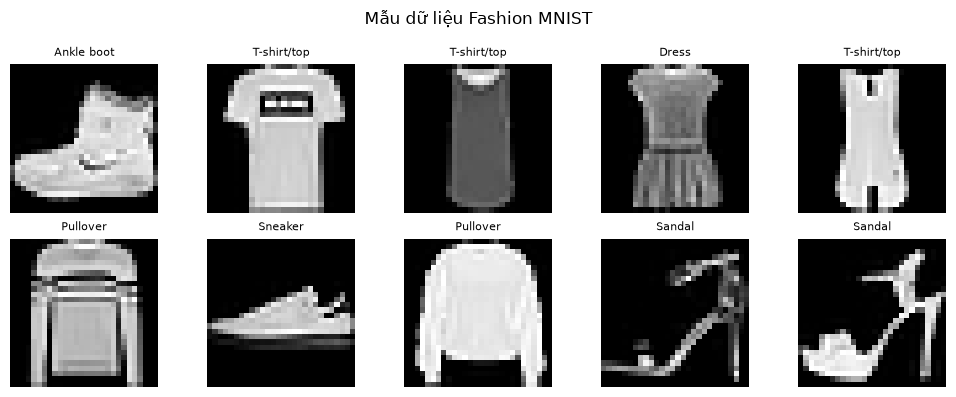

In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(class_names[y_train[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Mẫu dữ liệu Fashion MNIST')
plt.tight_layout()
plt.show()

## 3. Hàm hỗ trợ im2col / col2im

In [4]:
def get_im2col_indices(x_shape, fh, fw, padding=1, stride=1):
    N, C, H, W = x_shape
    out_h = (H + 2 * padding - fh) // stride + 1
    out_w = (W + 2 * padding - fw) // stride + 1
    i0 = np.repeat(np.arange(fh), fw)
    i0 = np.tile(i0, C)
    i1 = stride * np.repeat(np.arange(out_h), out_w)
    j0 = np.tile(np.arange(fw), fh * C)
    j1 = stride * np.tile(np.arange(out_w), out_h)
    i = i0.reshape(-1, 1) + i1.reshape(1, -1)
    j = j0.reshape(-1, 1) + j1.reshape(1, -1)
    k = np.repeat(np.arange(C), fh * fw).reshape(-1, 1)
    return (k, i, j)

def im2col_indices(x, fh, fw, padding=1, stride=1):
    p = padding
    x_pad = np.pad(x, ((0, 0), (0, 0), (p, p), (p, p)), mode='constant')
    k, i, j = get_im2col_indices(x.shape, fh, fw, padding, stride)
    cols = x_pad[:, k, i, j]
    C = x.shape[1]
    return cols.transpose(1, 2, 0).reshape(fh * fw * C, -1)

def col2im_indices(cols, x_shape, fh=3, fw=3, padding=1, stride=1):
    N, C, H, W = x_shape
    Hp, Wp = H + 2 * padding, W + 2 * padding
    x_pad = np.zeros((N, C, Hp, Wp), dtype=cols.dtype)
    k, i, j = get_im2col_indices(x_shape, fh, fw, padding, stride)
    cols_r = cols.reshape(C * fh * fw, -1, N).transpose(2, 0, 1)
    np.add.at(x_pad, (slice(None), k, i, j), cols_r)
    if padding == 0:
        return x_pad
    return x_pad[:, :, padding:-padding, padding:-padding]

print("OK helper functions")

OK helper functions


## 4. Các Layer (đã tối ưu)

In [5]:
class Conv2D:
    def __init__(self, in_c, out_c, k, stride=1, pad=1):
        self.W = np.random.randn(out_c, in_c, k, k) * np.sqrt(2. / (in_c * k * k))
        self.b = np.zeros(out_c)
        self.stride, self.pad = stride, pad
        self.x = self.x_col = self.W_col = None

    def forward(self, x):
        self.x = x
        n, c, h, w = x.shape
        oc, _, kh, kw = self.W.shape
        out_h = (h + 2*self.pad - kh)//self.stride + 1
        out_w = (w + 2*self.pad - kw)//self.stride + 1
        self.x_col = im2col_indices(x, kh, kw, self.pad, self.stride)
        self.W_col = self.W.reshape(oc, -1)
        out = self.W_col @ self.x_col + self.b.reshape(-1, 1)
        return out.reshape(oc, out_h, out_w, n).transpose(3, 0, 1, 2)

    def backward(self, dout):
        n, oc, oh, ow = dout.shape
        _, c, h, w = self.x.shape
        _, _, kh, kw = self.W.shape
        dout_r = dout.transpose(1, 2, 3, 0).reshape(oc, -1)
        self.dW = (dout_r @ self.x_col.T).reshape(self.W.shape)
        self.db = np.sum(dout, axis=(0, 2, 3))
        dx_col = self.W_col.T @ dout_r
        return col2im_indices(dx_col, self.x.shape, kh, kw, self.pad, self.stride)


class ReLU:
    def forward(self, x):
        self.mask = x > 0
        return x * self.mask
    def backward(self, dout):
        return dout * self.mask


class MaxPool2D:
    """Vectorized forward & backward — không dùng vòng lặp"""
    def __init__(self, size=2, stride=2):
        self.size, self.stride = size, stride

    def forward(self, x):
        self.x = x
        n, c, h, w = x.shape
        oh = (h - self.size)//self.stride + 1
        ow = (w - self.size)//self.stride + 1
        self.oh, self.ow = oh, ow
        shape = (n, c, oh, ow, self.size, self.size)
        strides = x.strides[:2] + (x.strides[2]*self.stride, x.strides[3]*self.stride) + x.strides[2:]
        self.x_str = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)
        return self.x_str.max(axis=(4, 5))

    def backward(self, dout):
        # dout: (n, c, oh, ow)
        # Bước 1: tìm vị trí max trong từng patch
        maxv = self.x_str.max(axis=(4, 5), keepdims=True)      # (n,c,oh,ow,1,1)
        mask = (self.x_str == maxv)                            # bool
        cnt = mask.sum(axis=(4, 5), keepdims=True)             # (n,c,oh,ow,1,1)
        # Bước 2: phân phối gradient
        dout_e = dout[:, :, :, :, None, None]                  # (n,c,oh,ow,1,1)
        g = mask * (dout_e / cnt)                              # (n,c,oh,ow,s,s)
        # Bước 3: rải về ảnh gốc không dùng vòng lặp
        dx = np.zeros_like(self.x)
        n, c, h, w = self.x.shape
        for i in range(self.size):
            for j in range(self.size):
                # view shape (n,c,oh,ow) và cộng vào vị trí tương ứng
                dx[:, :, i:i+self.oh*self.stride:self.stride,
                       j:j+self.ow*self.stride:self.stride] += g[:, :, :, :, i, j]
        return dx


class Flatten:
    def forward(self, x):
        self.shape = x.shape
        return x.reshape(x.shape[0], -1)
    def backward(self, dout):
        return dout.reshape(self.shape)


class Dense:
    def __init__(self, in_f, out_f):
        self.W = np.random.randn(in_f, out_f) * np.sqrt(2. / in_f)
        self.b = np.zeros(out_f)
    def forward(self, x):
        self.x = x
        return x @ self.W + self.b
    def backward(self, dout):
        self.dW = self.x.T @ dout
        self.db = np.sum(dout, axis=0)
        return dout @ self.W.T


class SoftmaxCrossEntropy:
    def forward(self, x, y):
        e = np.exp(x - np.max(x, axis=1, keepdims=True))
        self.probs = e / np.sum(e, axis=1, keepdims=True)
        n = x.shape[0]
        return -np.log(self.probs[np.arange(n), y] + 1e-8).mean()
    def backward(self, y):
        n = y.shape[0]
        dx = self.probs.copy()
        dx[np.arange(n), y] -= 1
        return dx / n

print("Đã định nghĩa xong layers")

Đã định nghĩa xong layers


## 5. Model

In [6]:
class CNNModel:
    def __init__(self):
        self.conv1 = Conv2D(1, 8, 3)
        self.relu1 = ReLU()
        self.pool1 = MaxPool2D(2, 2)
        self.conv2 = Conv2D(8, 16, 3)
        self.relu2 = ReLU()
        self.pool2 = MaxPool2D(2, 2)
        self.flatten = Flatten()
        self.fc1 = Dense(16 * 7 * 7, 64)
        self.relu3 = ReLU()
        self.fc2 = Dense(64, 10)
        self.loss_fn = SoftmaxCrossEntropy()
        self.layers = [self.conv1, self.relu1, self.pool1,
                       self.conv2, self.relu2, self.pool2,
                       self.flatten, self.fc1, self.relu3, self.fc2]

        # === Momentum buffers ===
        self.momentum = 0.9
        self.vW = {}
        self.vb = {}
        for i, l in enumerate(self.layers):
            if hasattr(l, 'W'):
                self.vW[i] = np.zeros_like(l.W)
                self.vb[i] = np.zeros_like(l.b)

    def forward(self, x):
        for l in self.layers:
            x = l.forward(x)
        return x

    def compute_loss_and_backward(self, x, y):
        logits = self.forward(x)
        loss = self.loss_fn.forward(logits, y)
        dout = self.loss_fn.backward(y)
        for l in reversed(self.layers):
            dout = l.backward(dout)
        return loss

    def update_weights(self, lr):
        for i, l in enumerate(self.layers):
            if hasattr(l, 'dW'):
                self.vW[i] = self.momentum * self.vW[i] - lr * l.dW
                self.vb[i] = self.momentum * self.vb[i] - lr * l.db
                l.W += self.vW[i]
                l.b += self.vb[i]

    # ===== 2 METHOD BỊ THIẾU Ở BẢN TRƯỚC =====
    def predict(self, x, bs=64):
        preds = []
        for i in range(0, len(x), bs):
            logits = self.forward(x[i:i+bs])
            preds.append(np.argmax(logits, axis=1))
        return np.concatenate(preds)

    def evaluate(self, x, y, bs=64):
        total, nb = 0.0, 0
        preds = []
        for i in range(0, len(x), bs):
            logits = self.forward(x[i:i+bs])
            total += self.loss_fn.forward(logits, y[i:i+bs])
            preds.append(np.argmax(logits, axis=1))
            nb += 1
        preds = np.concatenate(preds)
        return total / nb, accuracy_score(y, preds)

### Sanity check
Loss khởi tạo (10 lớp) phải ≈ 2.30. Nếu không, có lỗi forward.

In [7]:
m_test = CNNModel()
logits = m_test.forward(X_train[:8])
print("Logits shape:", logits.shape, "| NaN?", np.isnan(logits).any())
print(f"Init loss: {m_test.loss_fn.forward(logits, y_train[:8]):.4f}  (kỳ vọng ~2.30)")

Logits shape: (8, 10) | NaN? False
Init loss: 2.4558  (kỳ vọng ~2.30)


## 6. Training

In [8]:
model = CNNModel()
epochs = 15
batch_size = 32
lr = 0.01

train_loss_hist = []
epoch_train_loss, epoch_test_loss = [], []
epoch_train_acc,  epoch_test_acc  = [], []

print("Bắt đầu training...")
t0 = time.time()
for epoch in range(epochs):
    idx = np.random.permutation(N_TRAIN)
    Xs, ys = X_train[idx], y_train[idx]
    ep_loss, nb = 0.0, 0
    for i in range(0, N_TRAIN, batch_size):
        xb, yb = Xs[i:i+batch_size], ys[i:i+batch_size]
        if len(xb) == 0:
            continue
        loss = model.compute_loss_and_backward(xb, yb)
        model.update_weights(lr)
        ep_loss += loss
        nb += 1
        train_loss_hist.append(loss)
    avg_tr_loss = ep_loss / nb
    _, tr_acc = model.evaluate(X_train, y_train)
    te_loss, te_acc = model.evaluate(X_test, y_test)
    epoch_train_loss.append(avg_tr_loss)
    epoch_test_loss.append(te_loss)
    epoch_train_acc.append(tr_acc)
    epoch_test_acc.append(te_acc)
    print(f"Ep {epoch+1}/{epochs} | TrLoss {avg_tr_loss:.4f} TrAcc {tr_acc*100:.2f}% | "
          f"TeLoss {te_loss:.4f} TeAcc {te_acc*100:.2f}%")

print(f"\nTổng thời gian: {time.time()-t0:.1f}s")

Bắt đầu training...
Ep 1/15 | TrLoss 1.3226 TrAcc 72.70% | TeLoss 0.7358 TeAcc 73.80%
Ep 2/15 | TrLoss 0.6583 TrAcc 81.00% | TeLoss 0.6281 TeAcc 77.20%
Ep 3/15 | TrLoss 0.5513 TrAcc 84.45% | TeLoss 0.5591 TeAcc 80.60%
Ep 4/15 | TrLoss 0.4783 TrAcc 83.55% | TeLoss 0.5935 TeAcc 79.60%
Ep 5/15 | TrLoss 0.4156 TrAcc 86.00% | TeLoss 0.5445 TeAcc 81.20%
Ep 6/15 | TrLoss 0.3705 TrAcc 86.20% | TeLoss 0.4926 TeAcc 82.80%
Ep 7/15 | TrLoss 0.3589 TrAcc 90.45% | TeLoss 0.4752 TeAcc 82.80%
Ep 8/15 | TrLoss 0.3160 TrAcc 84.20% | TeLoss 0.6498 TeAcc 79.00%
Ep 9/15 | TrLoss 0.3301 TrAcc 89.00% | TeLoss 0.5377 TeAcc 82.40%
Ep 10/15 | TrLoss 0.2678 TrAcc 92.65% | TeLoss 0.4691 TeAcc 83.40%
Ep 11/15 | TrLoss 0.2397 TrAcc 93.85% | TeLoss 0.4926 TeAcc 83.20%
Ep 12/15 | TrLoss 0.2145 TrAcc 93.55% | TeLoss 0.5044 TeAcc 82.60%
Ep 13/15 | TrLoss 0.2037 TrAcc 93.15% | TeLoss 0.4745 TeAcc 84.20%
Ep 14/15 | TrLoss 0.1639 TrAcc 95.70% | TeLoss 0.4812 TeAcc 82.80%
Ep 15/15 | TrLoss 0.1495 TrAcc 95.80% | TeLoss 0.49

## 7. Đánh giá & Trực quan

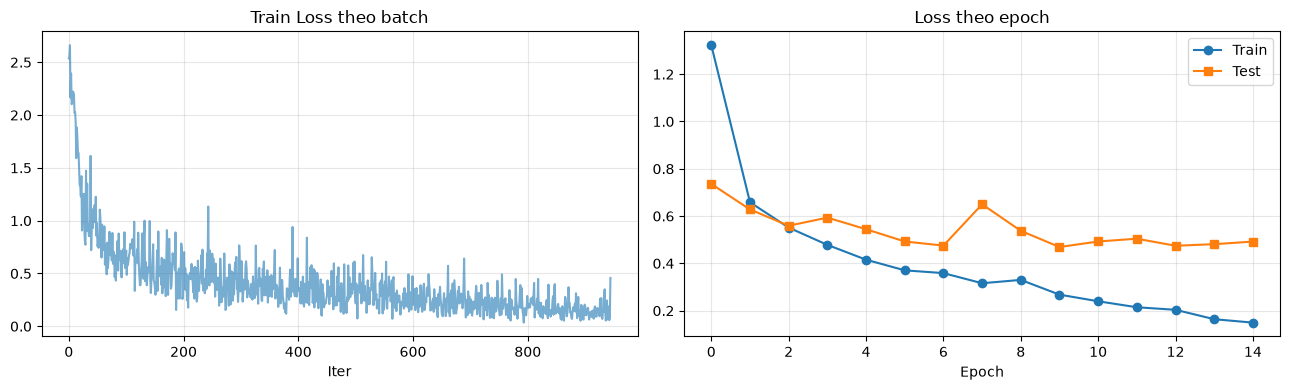

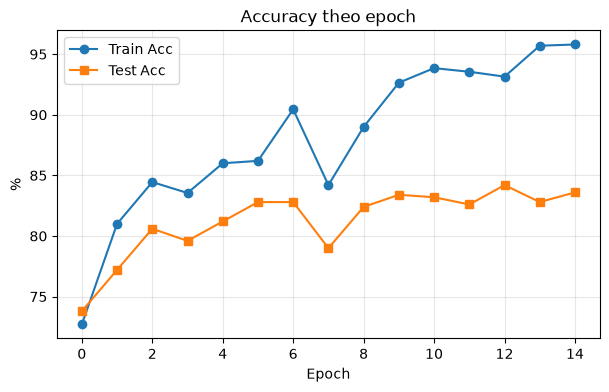

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_loss_hist, alpha=0.6)
axes[0].set_title('Train Loss theo batch'); axes[0].set_xlabel('Iter'); axes[0].grid(alpha=0.3)
axes[1].plot(epoch_train_loss, 'o-', label='Train')
axes[1].plot(epoch_test_loss, 's-', label='Test')
axes[1].set_title('Loss theo epoch'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 4))
plt.plot(np.array(epoch_train_acc)*100, 'o-', label='Train Acc')
plt.plot(np.array(epoch_test_acc)*100, 's-', label='Test Acc')
plt.title('Accuracy theo epoch'); plt.xlabel('Epoch'); plt.ylabel('%'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

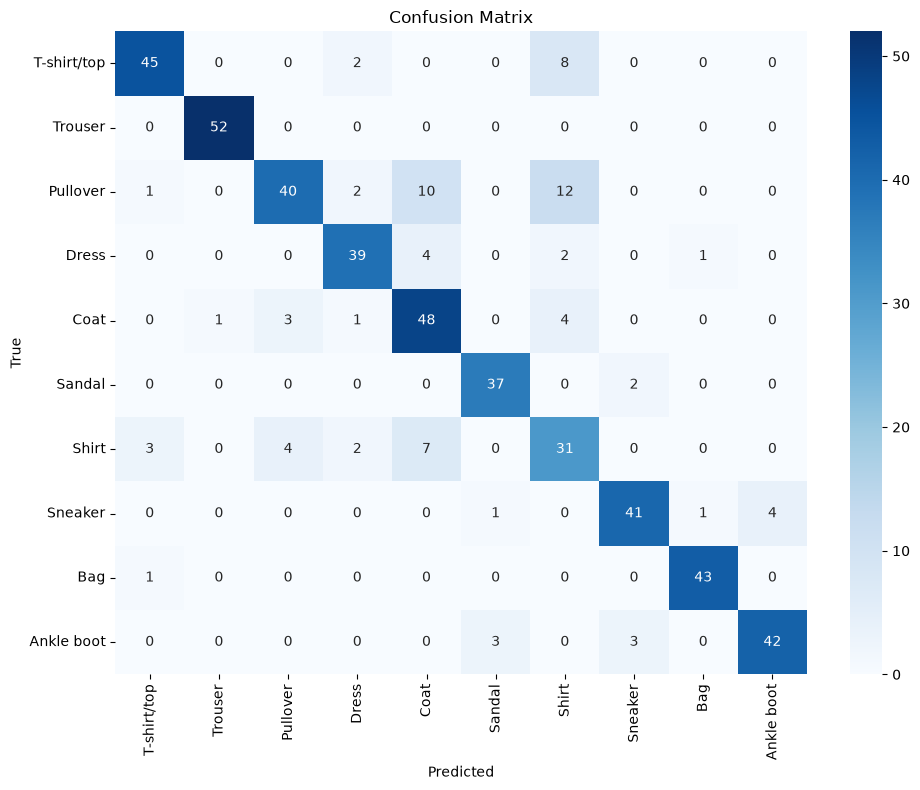

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 T-shirt/top     0.9000    0.8182    0.8571        55
     Trouser     0.9811    1.0000    0.9905        52
    Pullover     0.8511    0.6154    0.7143        65
       Dress     0.8478    0.8478    0.8478        46
        Coat     0.6957    0.8421    0.7619        57
      Sandal     0.9024    0.9487    0.9250        39
       Shirt     0.5439    0.6596    0.5962        47
     Sneaker     0.8913    0.8723    0.8817        47
         Bag     0.9556    0.9773    0.9663        44
  Ankle boot     0.9130    0.8750    0.8936        48

    accuracy                         0.8360       500
   macro avg     0.8482    0.8456    0.8434       500
weighted avg     0.8460    0.8360    0.8369       500



In [10]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.tight_layout(); plt.show()

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

In [11]:
final_tr_loss, final_tr_acc = model.evaluate(X_train, y_train)
final_te_loss, final_te_acc = model.evaluate(X_test, y_test)
print("=" * 45)
print("KẾT QUẢ CUỐI")
print("=" * 45)
print(f"Train Loss: {final_tr_loss:.4f} | Train Acc: {final_tr_acc*100:.2f}%")
print(f"Test  Loss: {final_te_loss:.4f} | Test  Acc: {final_te_acc*100:.2f}%")
print("=" * 45)

KẾT QUẢ CUỐI
Train Loss: 0.1262 | Train Acc: 95.80%
Test  Loss: 0.4922 | Test  Acc: 83.60%


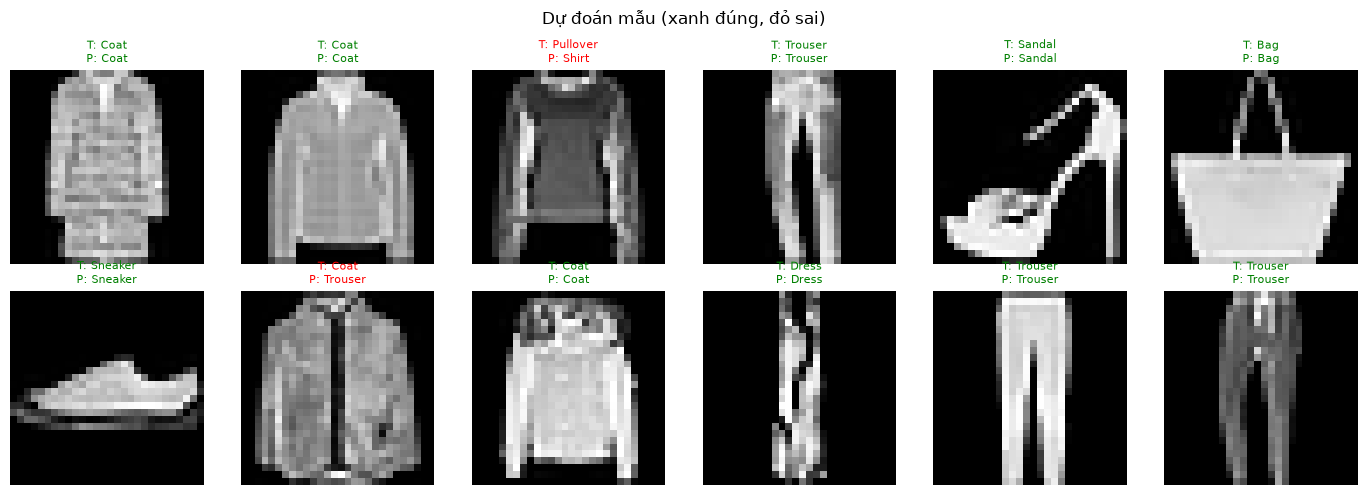

In [12]:
n_show = 12
idx = np.random.choice(len(X_test), n_show, replace=False)
X_show, y_show = X_test[idx], y_test[idx]
y_show_pred = model.predict(X_show)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_show[i].reshape(28, 28), cmap='gray')
    color = 'green' if y_show_pred[i] == y_show[i] else 'red'
    ax.set_title(f"T: {class_names[y_show[i]]}\nP: {class_names[y_show_pred[i]]}", color=color, fontsize=8)
    ax.axis('off')
plt.suptitle('Dự đoán mẫu (xanh đúng, đỏ sai)')
plt.tight_layout(); plt.show()

In [13]:
save_path = '../saved_models/fashion_mnist_numpy_fast.npz'
np.savez(save_path,
         conv1_W=model.conv1.W, conv1_b=model.conv1.b,
         conv2_W=model.conv2.W, conv2_b=model.conv2.b,
         fc1_W=model.fc1.W, fc1_b=model.fc1.b,
         fc2_W=model.fc2.W, fc2_b=model.fc2.b)
print(f"Đã lưu model vào {save_path}")

Đã lưu model vào ../saved_models/fashion_mnist_numpy_fast.npz
